In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Répertoires
pmf_dir = '../data/mono_data/popc-mono/pmfs/'
dist_dir = '../data/mono_data/popc-mono/distributions/'
output_dir = '../plot/'

# Constantes
k_B = 0.008314  # kJ/mol·K
T = 303.15
epsilon = 1e-5

In [8]:
def free_energy(pKa, charge):
    """Calcule l'énergie libre de référence pour les formes neutres"""
    R = 8.314e-3  # kJ/mol.K
    T = 302.3545798089109  # K
    pH = 7.0
    return -charge * R * T * np.log(10) * (pKa - pH)


def get_ref_per_acid(acid):
    """
    Retourne la correction d'énergie libre pour la forme neutre.
    Source: Platzer et al. (2014)
    pKa: ARG 13.9, LYS 10.34, ASP 3.86, GLU 4.34, HIS 6.45, CYS 8.49, TYR 9.76
    """
    # Pour la ref aux résidus chargés
    neutrals = ['SCHE', 'SCHD', 'SCKN', 'SCRN', 'SCDN', 'SCEN', 'SCC', 'SCY']
    pKas = [6.45, 6.45, 10.34, 13.9, 3.86, 4.34, 8.49, 9.76]
    charges = [1, 1, 1, 1, -1, -1, -1, -1]
    
    if acid in neutrals:
        return free_energy(pKas[neutrals.index(acid)], charges[neutrals.index(acid)])
    return 0


def PMF_residue(acid):
    """
    Charge directement le fichier PMF pré-calculé.
    Colonnes attendues: x, PMF_mean, std_error
    """
    return pd.read_table(pmf_dir + f'{acid}.dat'.lower(), sep=r"\s+")


def find_zero_density_limit(acid):
    """
    Trouve la valeur |z| la plus haute où la densité est 0 dans les 3 trajectoires.
    
    Parcourt les fichiers trajectory*.dat et trouve le z (en absolu) maximal
    où la densité est nulle (0.0) et qui se répète dans les 3 trajectoires.
    
    Returns:
        float: la limite z en dessous de laquelle les données sont invalides (densité nulle)
    """
    acid_dir = os.path.join(dist_dir, acid.lower())
    file_list = sorted(glob.glob(os.path.join(acid_dir, "trajectory*.dat")))
    
    if len(file_list) == 0:
        print(f"Attention: aucun fichier distribution trouvé pour {acid}")
        return 0.0
    
    # Pour chaque trajectoire, trouver les z (en absolu) où densité = 0
    zero_z_sets = []
    for filename in file_list:
        #la première colonne ne doit pas être utilisée comme index lors de la génération du DataFrame
        df = pd.read_csv(filename, sep=r'\s+', header=None, names=["x", "y", "e"], dtype={'x': float, 'y': float, 'e': float})
        # Prendre les valeurs absolues de z
        df['x_abs'] = df['x'].abs()
        #display(df)
        # Trouver les z où densité = 0
        df_z1 = df[df['y'] == 0.0]
        df_z2 = df_z1[df_z1['x_abs'] < 20.0]  # Exclure les z trop éloignés (>20 Å)
        zeros = df_z2['x_abs'].values
        #print(zeros)
        zero_z_sets.append(set(zeros))
    # Intersection: z où densité = 0 dans TOUTES les trajectoires
    common_zeros = zero_z_sets[0]
    for zset in zero_z_sets[1:]:
        common_zeros = common_zeros.intersection(zset)
    
    if len(common_zeros) == 0:
        return 0.0  # Pas de zéro commun
    
    # Retourner le z maximal (le plus éloigné de 0) où la densité est nulle
    return max(common_zeros)


def get_interval_btw_PMF(ref_data, new_data, correction, z_limit_ref=0.0, z_limit_new=0.0):
    """
    Calcule la différence d'énergie libre ΔG = PMF_new - PMF_ref + correction
    et propage l'erreur: SE = sqrt(SE_ref² + SE_new²)
    
    Args:
        ref_data: DataFrame avec x, PMF_mean, std_error (forme neutre)
        new_data: DataFrame avec x, PMF_mean, std_error (forme chargée)
        correction: correction d'énergie libre
        z_limit_ref: limite z pour la forme de référence (points < z_limit sont exclus)
        z_limit_new: limite z pour la nouvelle forme (points < z_limit sont exclus)
    
    Returns:
        DataFrame avec x, DG_mean, DG_std_error
    """
    # Fusionner sur x
    merged = pd.merge(ref_data, new_data, on='x', suffixes=('_ref', '_new'))
    
    # Filtrer les points en dessous des limites de densité nulle
    z_limit = max(z_limit_ref, z_limit_new)
    if z_limit > 0:
        merged = merged[merged['x'] >= z_limit].copy()
    
    # Calcul de ΔG
    merged['DG_mean'] = merged['PMF_mean_new'] - merged['PMF_mean_ref'] + correction
    
    # Propagation de l'erreur: sqrt(SE_ref² + SE_new²)
    merged['DG_std_error'] = np.sqrt(merged['std_error_ref']**2 + merged['std_error_new']**2)
    
    return merged[['x', 'DG_mean', 'DG_std_error']]

In [9]:
# Définition des acides aminés
aa_name = ['SCRN', 'SCR', 'SCKN', 'SCK', 'SCHE', 'SCHP',
           'SCDN', 'SCD', 'SCEN', 'SCE', 'SCC', 'SCCM', 'SCY', 'SCYM']

aa_symbol = ['ARGN', 'ARG', 'LYSN', 'LYS', 'HSE', 'HIS',
             'ASPN', 'ASP', 'GLUN', 'GLU', 'CYSN', 'CYS', 'TYRN', 'TYR']

aa_charge = [0, 1, 0, 1, 0, 1, 0, -1, 0, -1, 0, -1, 0, -1]


def pKa_func(DG, charge):
    """Convertit une différence d'énergie libre en pKa"""
    R = 8.314e-3  # kJ/mol.K
    T = 302.3545798089109  # K
    pH = 7.0
    return -DG / (charge * R * T * np.log(10)) + pH


def compute_pKa_dataframe(filter_plateau=False):
    """
    Calcule les pKa pour tous les acides aminés à partir des fichiers PMF pré-calculés.
    
    Args:
        filter_plateau: Si True, retire les points où la densité est nulle
                        (déterminé depuis les fichiers de distribution)
    
    Returns:
        DataFrame avec x, pKa et std pour chaque acide aminé
    """
    results_list = []
    
    for i in range(0, len(aa_name), 2):
        # Charger les PMF pré-calculés
        ref_data = PMF_residue(aa_name[i])      # Forme neutre
        new_data = PMF_residue(aa_name[i + 1])  # Forme chargée
        
        acid_s = aa_symbol[i + 1]
        charge = aa_charge[i + 1]
        correction = get_ref_per_acid(aa_name[i])
        
        # Trouver les limites z où la densité devient nulle
        if filter_plateau:
            z_limit_ref = find_zero_density_limit(aa_name[i])
            z_limit_new = find_zero_density_limit(aa_name[i + 1])
        else:
            z_limit_ref = 0.0
            z_limit_new = 0.0
        
        # Calcul de ΔG avec propagation d'erreur
        DG = get_interval_btw_PMF(ref_data, new_data, correction, 
                                   z_limit_ref=z_limit_ref, z_limit_new=z_limit_new)
        
        # Conversion en pKa
        DG['pKa'] = pKa_func(DG['DG_mean'], charge)
        # Propagation de l'erreur pour pKa: |dpKa/dDG| * SE_DG
        R = 8.314e-3
        T = 302.3545798089109
        DG['pKa_std'] = np.abs(1 / (charge * R * T * np.log(10))) * DG['DG_std_error']
        
        # Renommer les colonnes pour cet acide
        DG_renamed = DG[['x', 'pKa', 'pKa_std']].rename(columns={
            'pKa': f'pKa_{acid_s}',
            'pKa_std': f'std_{acid_s}'
        })
        results_list.append(DG_renamed)
    
    # Fusionner tous les résultats sur x
    result = results_list[0]
    for df in results_list[1:]:
        result = pd.merge(result, df, on='x', how='outer')
    
    return result.sort_values('x').reset_index(drop=True)


# Calcul des deux DataFrames
print("Calcul des pKa (tous points)...")
df_e = compute_pKa_dataframe(filter_plateau=False)  # Tous les points (avec plateau)

print("Calcul des pKa (sans plateau - basé sur densité nulle)...")
df_0 = compute_pKa_dataframe(filter_plateau=True)   # Sans les points au plateau

# Affichage des limites trouvées
print("\n=== Limites de densité nulle trouvées ===")
for i in range(0, len(aa_name), 2):
    z_ref = find_zero_density_limit(aa_name[i])
    z_new = find_zero_density_limit(aa_name[i + 1])
    print(f"{aa_symbol[i+1]}: ref ({aa_name[i]}) z_min={z_ref:.1f} Å, new ({aa_name[i+1]}) z_min={z_new:.1f} Å")

print("\n=== Résumé des calculs ===")
print("PMF chargés depuis fichiers .dat pré-calculés")
print("Erreur standard: sqrt(SE_ref² + SE_new²)")

print("\nExtrait pour z ∈ [0, 17] Å (tous points):")
display(df_e[(df_e['x'] > 0) & (df_e['x'] < 17)])

print("\nExtrait pour z ∈ [0, 17] Å (sans plateau):")
display(df_0[(df_0['x'] > 0) & (df_0['x'] < 17)])

Calcul des pKa (tous points)...
Calcul des pKa (sans plateau - basé sur densité nulle)...

=== Limites de densité nulle trouvées ===
ARG: ref (SCRN) z_min=0.0 Å, new (SCR) z_min=4.5 Å
LYS: ref (SCKN) z_min=0.0 Å, new (SCK) z_min=3.5 Å
HIS: ref (SCHE) z_min=5.5 Å, new (SCHP) z_min=11.5 Å
ASP: ref (SCDN) z_min=0.0 Å, new (SCD) z_min=10.5 Å
GLU: ref (SCEN) z_min=0.0 Å, new (SCE) z_min=9.5 Å
CYS: ref (SCC) z_min=0.0 Å, new (SCCM) z_min=9.5 Å
TYR: ref (SCY) z_min=0.0 Å, new (SCYM) z_min=6.5 Å

=== Résumé des calculs ===
PMF chargés depuis fichiers .dat pré-calculés
Erreur standard: sqrt(SE_ref² + SE_new²)

Extrait pour z ∈ [0, 17] Å (tous points):


,x,pKa_ARG,std_ARG,pKa_LYS,std_LYS,pKa_HIS,std_HIS,pKa_ASP,std_ASP,pKa_GLU,std_GLU,pKa_CYS,std_CYS,pKa_TYR,std_TYR
0,0.5,11.960722,0.649643,7.325539,0.057857,6.371436,0.028403,4.890739,0.072975,6.071671,0.096582,12.829516,0.054248,12.901955,0.096221
1,1.5,11.908210,0.584313,7.325539,0.057857,6.371436,0.028403,4.854811,0.057518,6.126942,0.118601,12.818300,0.058711,12.932979,0.114488
2,2.5,11.796461,0.452518,7.325539,0.057857,6.371436,0.028403,4.869475,0.053668,6.283019,0.147740,12.796607,0.057703,13.004503,0.153931
3,3.5,11.657577,0.303691,7.636446,0.204567,6.371436,0.028403,5.105583,0.034856,6.526387,0.124482,12.764897,0.059033,13.136482,0.222551
4,4.5,11.454784,0.165415,8.168365,0.469965,6.371436,0.028403,5.504764,0.041913,6.812730,0.074773,12.729106,0.060744,13.313296,0.296980
5,5.5,11.324613,0.148423,8.364766,0.567149,6.235264,0.135962,5.932676,0.055642,7.121386,0.039428,12.689087,0.060290,13.512319,0.357146
6,6.5,11.526827,0.151002,8.573541,0.674736,5.757544,0.028274,6.318039,0.043932,7.409068,0.032831,12.672878,0.059261,13.633654,0.401422
7,7.5,11.959432,0.203934,9.107690,0.445913,5.403890,0.038077,6.670023,0.047792,7.681922,0.033260,12.696396,0.060244,13.754193,0.431101
8,8.5,12.352700,0.182141,9.601130,0.308167,4.993907,0.034801,6.964512,0.034571,7.911780,0.025807,12.747119,0.060823,13.599459,0.454017
9,9.5,12.673656,0.149030,10.000488,0.230574,4.579528,0.033052,7.202902,0.030734,8.104307,0.021382,12.820429,0.060219,13.379969,0.464956



Extrait pour z ∈ [0, 17] Å (sans plateau):


,x,pKa_ARG,std_ARG,pKa_LYS,std_LYS,pKa_HIS,std_HIS,pKa_ASP,std_ASP,pKa_GLU,std_GLU,pKa_CYS,std_CYS,pKa_TYR,std_TYR
0,3.5,NaN,NaN,7.636446,0.204567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.5,11.454784,0.165415,8.168365,0.469965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.5,11.324613,0.148423,8.364766,0.567149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.5,11.526827,0.151002,8.573541,0.674736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.633654,0.401422
4,7.5,11.959432,0.203934,9.107690,0.445913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.754193,0.431101
5,8.5,12.352700,0.182141,9.601130,0.308167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.599459,0.454017
6,9.5,12.673656,0.149030,10.000488,0.230574,NaN,NaN,NaN,NaN,8.104307,0.021382,12.820429,0.060219,13.379969,0.464956
7,10.5,12.899419,0.131903,10.315484,0.175552,NaN,NaN,7.348882,0.059181,8.223050,0.023333,12.890391,0.055656,13.068562,0.461431
8,11.5,13.122723,0.103801,10.542117,0.151605,3.910164,0.030833,7.436388,0.071293,8.211237,0.038869,12.899474,0.059957,12.709799,0.463110
9,12.5,13.314448,0.092583,10.695044,0.133737,4.244544,0.141379,7.424944,0.102236,8.053268,0.068170,12.756508,0.115336,12.406369,0.459120


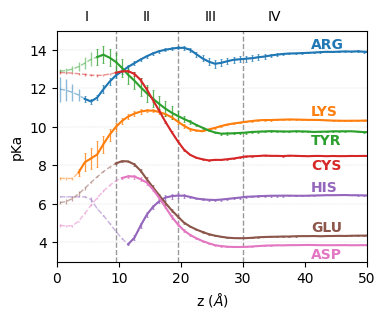

In [10]:
# Plot des pKa
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(4, 3))
list_aa = ['ARG', 'LYS', 'TYR', 'CYS', 'HIS', 'GLU', 'ASP']

for i, name in enumerate(list_aa):
    # Données sans plateau (ligne pleine)
    mask_0 = df_0['x'].notna() & df_0[f'pKa_{name}'].notna()
    x1 = df_0.loc[mask_0, 'x']
    y1 = df_0.loc[mask_0, f'pKa_{name}']
    e1 = df_0.loc[mask_0, f'std_{name}']
    
    # Données avec plateau (ligne pointillée)
    mask_e = df_e['x'].notna() & df_e[f'pKa_{name}'].notna()
    x2 = df_e.loc[mask_e, 'x']
    y2 = df_e.loc[mask_e, f'pKa_{name}']
    e2 = df_e.loc[mask_e, f'std_{name}']
    
    plt.errorbar(x1, y1, e1, linewidth=1.5, color=color[i], elinewidth=0.4, capthick=0.4, capsize=1)
    plt.errorbar(x2, y2, e2, linewidth=1, color=color[i], linestyle='dashed', alpha=0.5)
    
    # Label à droite
    if len(y1) > 0:
        # Trouver la valeur à z ≈ 40 Å pour positionner le texte
        idx_40 = (x1 - 40).abs().idxmin() if len(x1) > 0 else None
        if idx_40 is not None and idx_40 in y1.index:
            y_pos = y1.loc[idx_40]
            if name not in ['ASP', 'TYR', 'CYS']:
                plt.text(41, y_pos + 0.2, name, weight="bold", color=color[i])
            else:
                plt.text(41, y_pos - 0.7, name, weight="bold", color=color[i])

# Grille verticale personnalisée (lignes à 9.5, 19.5, 30) - en dehors de la boucle
custom_vgrid = [9.5, 19.5, 30]
for xv in custom_vgrid:
    plt.axvline(x=xv, linestyle='--', alpha=0.8, linewidth=1, color='gray', zorder=0)

# Grille horizontale
plt.gca().yaxis.grid(True, which='major', linestyle='--', alpha=0.5, linewidth=0.3)

# Chiffres romains en haut pour les zones membranaires
roman_numerals = [('I', 4.75), ('II', 14.5), ('III', 24.75), ('IV', 35)]
for numeral, x_pos in roman_numerals:
    plt.text(x_pos, 1.03, numeral, transform=plt.gca().get_xaxis_transform(),
             ha='center', va='bottom', fontsize=10, fontweight='normal')

plt.xlim([0, 50])
plt.ylim([3, 15])
plt.xlabel('z ($\AA$)')
plt.ylabel('pKa')
plt.savefig(output_dir + 'pKa.png', bbox_inches='tight', transparent=True, dpi=800)
plt.show()